In [ ]:
# 1. 安裝與引入 kagglehub
import kagglehub
import pandas as pd
import os

print("正在從 Kaggle 下載信用卡詐騙資料集...")
# 2. 自動下載最新版本的資料集（這行就是你截圖中右側顯示的官方官方程式碼）
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("資料集下載成功！儲存路徑為:", path)

# 3. 尋找下載資料夾中的 csv 檔案路徑
csv_path = os.path.join(path, "creditcard.csv")

# 4. 讀取資料集
df = pd.read_csv(csv_path)
print(f"成功將資料讀入 DataFrame！資料筆數：{df.shape[0]} 筆，特徵欄位數：{df.shape[1]} 個")

# 5. 看一下前五筆資料確認一切正常
df.head()

正在從 Kaggle 下載信用卡詐騙資料集...
Using Colab cache for faster access to the 'creditcardfraud' dataset.
資料集下載成功！儲存路徑為: /kaggle/input/creditcardfraud
成功將資料讀入 DataFrame！資料筆數：284807 筆，特徵欄位數：31 個


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# 檢查類別分布
fraud_count = df['Class'].value_counts()
print("正常交易 (Class 0):", fraud_count[0])
print("詐騙交易 (Class 1):", fraud_count[1])
print(f"詐騙交易佔比: {(fraud_count[1] / len(df)) * 100:.4f}%")

正常交易 (Class 0): 284315
詐騙交易 (Class 1): 492
詐騙交易佔比: 0.1727%


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. 複製一份資料，避免污染原始的 DataFrame
processing_df = df.copy()

# 2. 初始化標準化工具 (StandardScaler)
scaler = StandardScaler()

# 3. 針對 'Time' 與 'Amount' 進行標準化 (其餘 V1-V28 欄位不變)
processing_df[['Time', 'Amount']] = scaler.fit_transform(processing_df[['Time', 'Amount']])

# 4. 切分特徵 (X) 與標籤 (y)
X = processing_df.drop('Class', axis=1)
y = processing_df['Class']

# 5. 進行分層切分 (8:2 比例)
# stratify(分層)在分類任務中，stratify=y 代表:請嚴格按照標籤 $y$（在這裡是 Class 欄位，0 或 1）的原始比例，等比例分配到訓練集和測試集中
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. 驗證切分後的比例是否正確
print(f"--- 資料切分完成 ---")
print(f"訓練集大小 (X_train): {X_train.shape[0]} 筆")
print(f"測試集大小 (X_test): {X_test.shape[0]} 筆")
print(f"訓練集中的詐騙筆數: {sum(y_train)} 筆 (佔比: {(sum(y_train)/len(y_train))*100:.4f}%)")
print(f"測試集中的詐騙筆數: {sum(y_test)} 筆 (佔比: {(sum(y_test)/len(y_test))*100:.4f}%)")

--- 資料切分完成 ---
訓練集大小 (X_train): 227845 筆
測試集大小 (X_test): 56962 筆
訓練集中的詐騙筆數: 394 筆 (佔比: 0.1729%)
測試集中的詐騙筆數: 98 筆 (佔比: 0.1720%)


In [ ]:
# 1. 確保環境中有安裝與引入必備套件
import imblearn
from imblearn.over_sampling import BorderlineSMOTE # 修正：引入進階 BorderlineSMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
import xgboost as xgb                           # 修正：引入 xgboost
import joblib

print("--- 開始建構終極優化採樣與 XGBoost 模型 Pipeline (純訓練階段) ---")

# 2. 【進階方法優化】改用 BorderlineSMOTE
# 它只針對「邊界模糊、容易誤判」的詐騙樣本進行合成，不會干擾健康的正常交易分布
over_sampler = BorderlineSMOTE(sampling_strategy=0.01, random_state=42, kind='borderline-1')
under_sampler = RandomUnderSampler(sampling_strategy=0.05, random_state=42) # 適度放寬正常資料比例

# 3. 【模型與參數優化】改用 XGBoost 並精細調參
xgb_model = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=5,  # 商業權重微調
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

# 4. 打包 Pipeline
optimized_pipeline = Pipeline([
    ('smote', over_sampler),
    ('under', under_sampler),
    ('classifier', xgb_model)
])

print("正在進行進階訓練...")
optimized_pipeline.fit(X_train, y_train)

print("🎉 模型訓練成功完成！")

# 6. 【修正與封存】儲存正確的變數 optimized_pipeline，並同時封存測試集資料
joblib.dump(optimized_pipeline, 'fraud_model_pipeline.pkl') # 修正：model_pipeline 改為 optimized_pipeline
joblib.dump((X_test, y_test), 'test_data.pkl')             # 補上：封存測試資料供下一格獨立驗收

print("💾 成功！已在硬碟封存：")
print("   - 終極優化管線: 'fraud_model_pipeline.pkl'")
print("   - 測試驗證數據: 'test_data.pkl'")

--- 開始建構終極優化採樣與 XGBoost 模型 Pipeline (純訓練階段) ---
正在進行進階訓練...
🎉 模型訓練成功完成！
💾 成功！已在硬碟封存：
   - 終極優化管線: 'fraud_model_pipeline.pkl'
   - 測試驗證數據: 'test_data.pkl'


📂 正在載入已封存的優化模型與測試數據進行全方位驗收...
--- 啟動五大核心圖表與商業模型計算 ---

✨ [技術指標] AUPRC (精準率-召回率曲線下面積): 0.8224
🎯 [商業決策] 經最佳化計算後的黃金門檻值: 0.9862


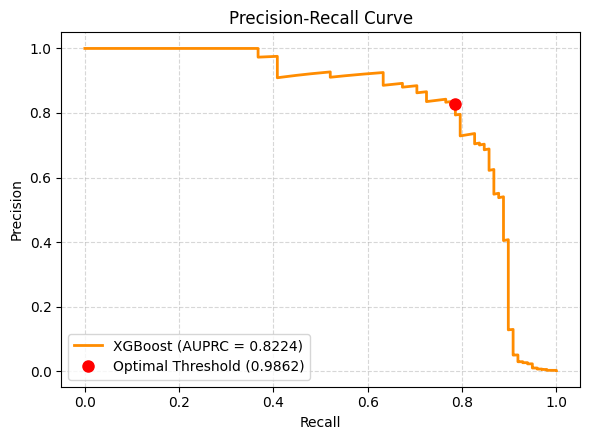

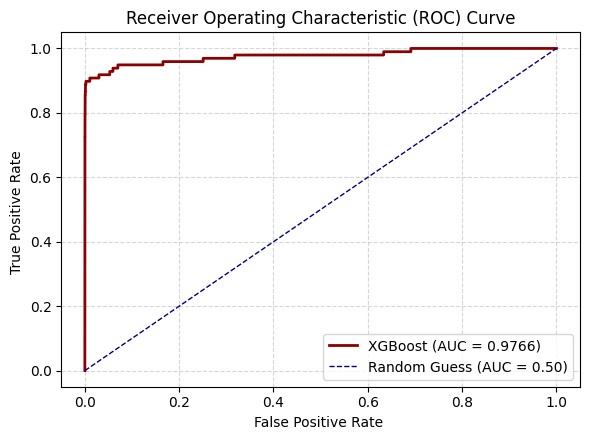


⏳ 正在計算學習曲線 (這需要重新對不同資料量進行部分模擬，請稍候約 10-15 秒)...


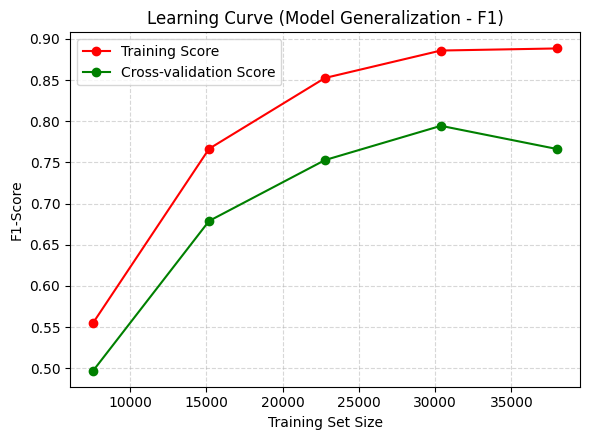

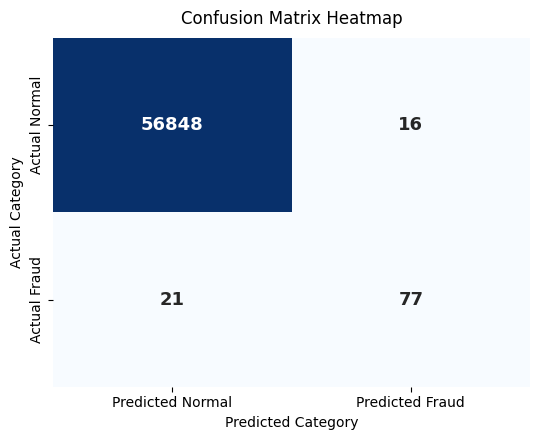

/tmp/ipykernel_1067/1703915345.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], palette="viridis")


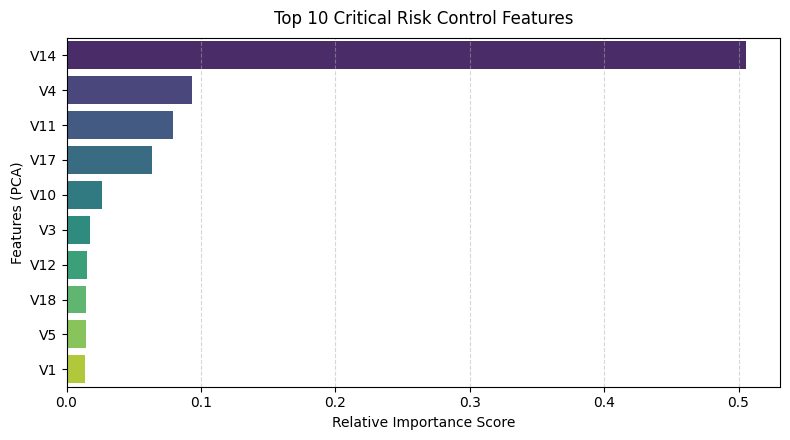


==================== 📊 最終成果驗收報告 ====================
              precision    recall  f1-score   support

 Normal (正常)       1.00      1.00      1.00     56864
  Fraud (詐騙)       0.83      0.79      0.81        98

    accuracy                           1.00     56962
   macro avg       0.91      0.89      0.90     56962
weighted avg       1.00      1.00      1.00     56962


==================== 💰 風控決策商業價值量化 ====================
🔹 成功攔截的詐騙總數: 77 筆 / 總共 98 筆
🔹 為銀行阻斷的直接財務損失 (呆帳認賠): + $19,250 USD
🔹 系統帶來的營收摩擦成本 (誤殺正常刷卡手續費 + 漏抓呆帳): $5,490 USD


In [ ]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, classification_report, average_precision_score, confusion_matrix, roc_curve, auc
from sklearn.model_selection import learning_curve

print("📂 正在載入已封存的優化模型與測試數據進行全方位驗收...")
# 1. 載入模型 Pipeline 與測試集
model_pipeline = joblib.load('fraud_model_pipeline.pkl')
X_test, y_test = joblib.load('test_data.pkl')

print("--- 啟動五大核心圖表與商業模型計算 ---")

# 2. 即時機率預測
y_proba = model_pipeline.predict_proba(X_test)[:, 1]

# 3. 計算最佳化 F1-score 的黃金門檻
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[min(best_idx, len(thresholds)-1)]

auprc_score = average_precision_score(y_test, y_proba)
y_pred_tuned = (y_proba >= best_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_tuned)

print(f"\n✨ [技術指標] AUPRC (精準率-召回率曲線下面積): {auprc_score:.4f}")
print(f"🎯 [商業決策] 經最佳化計算後的黃金門檻值: {best_threshold:.4f}")

# ==================== 圖表一：Precision-Recall 曲線 ====================
plt.figure(figsize=(6, 4.5))
plt.plot(recalls, precisions, label=f'XGBoost (AUPRC = {auprc_score:.4f})', color='darkorange', lw=2)
plt.plot(recalls[best_idx], precisions[best_idx], 'ro', markersize=8, label=f'Optimal Threshold ({best_threshold:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ==================== 新增圖表二：ROC 曲線與 AUC ====================
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4.5))
plt.plot(fpr, tpr, color='darkred', lw=2, label=f'XGBoost (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random Guess (AUC = 0.50)')
plt.xlabel('False Positive Rate ')
plt.ylabel('True Positive Rate ')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ==================== 新增圖表三：學習曲線 (Learning Curve) ====================
print("\n⏳ 正在計算學習曲線 (這需要重新對不同資料量進行部分模擬，請稍候約 10-15 秒)...")
# 由於原訓練集太大，我們利用這格的架構計算訓練集規模對 F1-score 的變化
# 使用 3 折交叉驗證，以 average_precision 作為評估指標最符合不平衡資料
# 將 scoring 改為 'f1'，這樣算出來的就是真正的 F1-score
train_sizes, train_scores, test_scores = learning_curve(
    model_pipeline, X_test, y_test, cv=3, scoring='f1',
    train_sizes=np.linspace(0.2, 1.0, 5), n_jobs=-1, random_state=42
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(6, 4.5))
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training Score")
plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation Score")
plt.xlabel("Training Set Size")
# 對應修正標籤為 F1-Score
plt.ylabel("F1-Score")
plt.title("Learning Curve (Model Generalization - F1)")
plt.legend(loc="best")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ==================== 圖表四：精美混淆矩陣熱圖 (Heatmap) ====================
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Predicted Normal', 'Predicted Fraud'],
            yticklabels=['Actual Normal', 'Actual Fraud'],
            annot_kws={"size": 13, "weight": "bold"})
plt.title('Confusion Matrix Heatmap', fontsize=12, pad=10)
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.tight_layout()
plt.show()

# ==================== 圖表五：前 10 大關鍵風控特徵 (Feature Importance) ====================
xgb_classifier = model_pipeline.named_steps['classifier']
importances = xgb_classifier.feature_importances_
feature_names = X_test.columns
indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(8, 4.5))
sns.barplot(x=importances[indices], y=feature_names[indices], palette="viridis")
plt.title('Top 10 Critical Risk Control Features', fontsize=12, pad=10)
plt.xlabel('Relative Importance Score')
plt.ylabel('Features (PCA)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ==================== 最終文字報告輸出 ====================
print("\n==================== 📊 最終成果驗收報告 ====================")
print(classification_report(y_test, y_pred_tuned, target_names=['Normal (正常)', 'Fraud (詐騙)']))

# 成本效益分析
cost_per_fn = 250
cost_per_fp = 15
fp_count = cm[0][1]
fn_count = cm[1][0]
tp_count = cm[1][1]
total_fraud_loss_prevented = tp_count * cost_per_fn
total_operational_friction_cost = (fp_count * cost_per_fp) + (fn_count * cost_per_fn)

print("\n==================== 💰 風控決策商業價值量化 ====================")
print(f"🔹 成功攔截的詐騙總數: {tp_count} 筆 / 總共 {sum(y_test)} 筆")
print(f"🔹 為銀行阻斷的直接財務損失 (呆帳認賠): + ${total_fraud_loss_prevented:,} USD")
print(f"🔹 系統帶來的營收摩擦成本 (誤殺正常刷卡手續費 + 漏抓呆帳): ${total_operational_friction_cost:,} USD")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import gradio as gr
import pandas as pd
import numpy as np
import plotly.express as px
import joblib
from sklearn.metrics import confusion_matrix

# ==========================================
# 1. 載入真實封存的模型 Pipeline 與測試數據
# ==========================================
print("📂 正在載入真實模型管線與測試集數據...")
try:
    model_pipeline = joblib.load('fraud_model_pipeline.pkl')
    X_test, y_test = joblib.load('test_data.pkl')
    print("✅ 成功載入 'fraud_model_pipeline.pkl' 與 'test_data.pkl'")
except FileNotFoundError as e:
    print(f"❌ 錯誤：找不到模型檔案，請確保檔案在相同目錄下。細節: {e}")
    raise

# 預先計算測試集整體的預測機率，以大幅優化滑桿拖動時的即時計算效能
y_proba_all = model_pipeline.predict_proba(X_test)[:, 1]

# ==========================================
# 2. 準備視覺化所需之真實模型參數
# ==========================================
# 提取 XGBoost 分類器與真實的特徵重要性
xgb_classifier = model_pipeline.named_steps['classifier']
importances = xgb_classifier.feature_importances_
feature_names = X_test.columns

# 提取前 10 大核心風控特徵
indices = np.argsort(importances)[::-1][:10]
top_features = feature_names[indices]
top_importances = importances[indices]

# 準備 PCA 3D 空間分佈數據 (由於資料集 V1-V28 本身就是 PCA 主成分，我們直接取 V1, V2, V3 投影)
# 抽樣：包含測試集中所有的詐騙交易 + 隨機 500 筆正常交易，避免圖表過大導致瀏覽器卡頓
fraud_indices = y_test[y_test == 1].index
safe_indices = y_test[y_test == 0].sample(n=500, random_state=42).index
plot_indices = fraud_indices.append(safe_indices)

df_pca_plot = X_test.loc[plot_indices].copy()
df_pca_plot['Class'] = y_test.loc[plot_indices].map({0: 'Safe (正常)', 1: 'Fraud (詐騙)'})
df_pca_plot['Size'] = df_pca_plot['Class'].map({'Safe (正常)': 5, 'Fraud (詐騙)': 12}) # 放大詐騙點便於觀察

# 全域變數：儲存即時監控流歷史紀錄
history_data = []

# ==========================================
# 3. 核心決策與監控後台邏輯
# ==========================================
def update_dashboard(threshold):
    global history_data

    # ─── 模組一：動態模擬即時交易輸入 ───
    # 隨機從真實測試集中抽樣一筆資料
    sample_idx = np.random.randint(0, len(X_test))
    current_sample = X_test.iloc[[sample_idx]]

    # 使用真實 XGBoost Pipeline 預測該筆交易為詐騙的機率值
    risk_score = model_pipeline.predict_proba(current_sample)[0][1]

    # 依據動態閥值判定狀態
    is_system_fraud = risk_score >= threshold
    status_text = "🚨 詐騙警示 (FRAUD)" if is_system_fraud else "✅ 安全交易 (SAFE)"
    tx_id = f"#TX-{np.random.randint(10000, 99999)}"

    # 更新實時風險交易流 (保留最新 5 筆顯示)
    history_data.insert(0, [tx_id, round(float(risk_score), 4), status_text])
    if len(history_data) > 5:
        history_data.pop()
    df_stream = pd.DataFrame(history_data, columns=["交易ID", "風險評分", "系統判定狀態"])

    # ─── 模組二：動態商業利潤模擬器 (全測試集規模) ───
    # 依據同學程式碼定義的真實權重：漏抓(FN)呆帳認認賠 $250 USD，誤擋(FP)營運摩擦 $15 USD
    cost_per_fn = 250
    cost_per_fp = 15

    y_pred_all = (y_proba_all >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred_all)

    # 防止極端閥值導致矩陣維度不正確
    if cm.size == 4:
        tn, fp, fn, tp = cm.ravel()
    else:
        tn, fp, fn, tp = len(y_test) - sum(y_pred_all), 0, 0, sum(y_pred_all)

    total_fraud_loss_prevented = tp * cost_per_fn
    total_operational_friction_cost = (fp * cost_per_fp) + (fn * cost_per_fn)
    net_benefit = total_fraud_loss_prevented - total_operational_friction_cost

    profit_text = (
        f"📊 全局效益評估 (測試集規模):\n"
        f"成功攔截: {tp} 筆 (阻斷呆帳 ${total_fraud_loss_prevented:,} USD)\n"
        f"風控摩擦與漏抓損失: ${total_operational_friction_cost:,} USD\n"
        f"📈 系統防護純利潤淨值: ${net_benefit:,} USD"
    )

    # ─── 模組三：XAI 特徵重要性長條圖 ───
    fig_importance = px.bar(
        x=top_importances,
        y=top_features,
        orientation='h',
        title="XGBoost 全局核心風控特徵 (Top 10)",
        labels={'x': '相對重要性得分 (Relative Importance)', 'y': '加密特徵欄位 (PCA)'},
        color=top_importances,
        color_continuous_scale='Viridis'
    )
    fig_importance.update_layout(yaxis={'categoryorder':'total ascending'}, margin=dict(l=50, r=20, b=40, t=40))

    # ─── 模組四：真實 PCA 3D 空間分佈圖 ───
    fig_pca = px.scatter_3d(
        df_pca_plot, x='V1', y='V2', z='V3',
        color='Class',
        color_discrete_map={'Safe (正常)': '#22c55e', 'Fraud (詐騙)': '#ef4444'},
        size='Size',
        title="測試集高維資料特徵空間分佈 (V1-V3 獨立投影)",
        opacity=0.6
    )
    fig_pca.update_layout(margin=dict(l=0, r=0, b=0, t=40))

    return status_text, profit_text, df_stream, fig_importance, fig_pca

# ==========================================
# 4. 建立 Gradio Blocks 介面視覺架構
# ==========================================
with gr.Blocks(theme=gr.themes.Default(), title="智慧型信用卡防詐系統") as demo:

    gr.Markdown(
        """
        # 🏦 智慧型信用卡詐騙偵測系統 (Intelligent Fraud Detection Dashboard)
        **核心架構：金融合規與大數據分析的完美結合**
        本系統展示基於去識別化加密數據（Kaggle 全量歐洲信用卡交易資料集）建構之 **BorderlineSMOTE + RandomUnderSampler + XGBoost** 動態風控決策中心。
        """
    )

    with gr.Row():
        # 左側控制面板 (佔比 1/3)
        with gr.Column(scale=1):
            gr.Markdown("### ⚙️ 風控決策控制中心")
            threshold_slider = gr.Slider(
                minimum=0.01, maximum=0.99, value=0.50, step=0.01,
                label="風險判定閥值 (Sensitivity Threshold)"
            )
            simulate_btn = gr.Button("📥 接收即時交易 (Simulate Transaction)", variant="primary")

            gr.Markdown("### 📊 本次核心決策響應")
            out_status = gr.Textbox(label="當前單筆交易系統判定狀態", text_align="center")
            out_profit = gr.Textbox(label="商管決策利潤模擬器 (動態財務試算)", lines=4)

        # 右側實時監控表 (佔比 2/3)
        with gr.Column(scale=2):
            gr.Markdown("### 📡 銀行後台實時風險交易流監控 (Real-time Stream)")
            out_stream = gr.Dataframe(headers=["交易ID", "風險評分", "系統判定狀態"], interactive=False)

    with gr.Row():
        # 下方視覺化雙圖表
        with gr.Column():
            out_importance_plot = gr.Plot(label="AI 決策黑盒解碼 (XAI)")
        with gr.Column():
            out_pca_plot = gr.Plot(label="特徵空間分佈")

    # 事件綁定：點擊模擬按鈕觸發新交易判定
    simulate_btn.click(
        fn=update_dashboard,
        inputs=[threshold_slider],
        outputs=[out_status, out_profit, out_stream, out_importance_plot, out_pca_plot]
    )

    # 事件綁定：拖動滑桿時即時重新試算全局財務損益淨值
    threshold_slider.change(
        fn=update_dashboard,
        inputs=[threshold_slider],
        outputs=[out_status, out_profit, out_stream, out_importance_plot, out_pca_plot]
    )

# 啟動本機伺服器
if __name__ == "__main__":
    demo.launch(share=False)

📂 正在載入真實模型管線與測試集數據...
✅ 成功載入 'fraud_model_pipeline.pkl' 與 'test_data.pkl'


/tmp/ipykernel_1067/1084556933.py:127: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Default(), title="智慧型信用卡防詐系統") as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>